### Analyze $N^2$, $M^2$, and energetics in idealized beaufort jet

In [30]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as tick
import numpy as np
import xarray as xr
import xroms
import cartopy
from matplotlib.colors import BoundaryNorm
import cmocean.cm as cmo
import xarray as xr
from netCDF4 import Dataset
# from mpas_analysis.shared.io.utility import decode_strings
from glob import glob
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.feature as cfeature
import cmocean.cm as cmo
from matplotlib import ticker
from xhistogram.xarray import histogram
from matplotlib.ticker import FuncFormatter

import warnings 
warnings.filterwarnings("ignore") #turns off annoying warnings

In [7]:
# Paths
grd_file = '/pscratch/sd/d/dylan617/beaufort_roms/runs_idealized/inputs/grd_1000_m.nc'
his_file = '/pscratch/sd/d/dylan617/beaufort_roms/runs_idealized/outputs/roms_avg_ice_w_dvd_dx_1000m*.nc'
# Load dataset
ds = xroms.open_mfnetcdf(glob(his_file))
# Remove the boundary cells otherwise periodic BC will 
# cause the x_rho indexing to have overlapping values. This will NOT 
# allow you plot or calculate gradients correctly. Just change h = None
# to test this!
h = 1 
slices = dict(
    xi_rho = slice(h, -h),
    eta_rho = slice(h, -h),
    xi_u   = slice(h, -h),
    eta_v  = slice(h, -h),
)

ds = ds.isel(**slices)
# === Rebuild ROMS dataset + grid (now halo-free) ===
ds, grid = xroms.roms_dataset(ds,include_cell_volume=True)
# Print this to confirm 
# ds.x_rho.values
# ds.x_u.values

<xarray.Dataset> Size: 278GB
Dimensions:             (tracer: 8, s_rho: 40, s_w: 41, eta_rho: 248,
                         xi_rho: 198, xi_u: 197, eta_v: 247, ocean_time: 606)
Coordinates: (12/21)
  * s_rho               (s_rho) float64 320B -0.9875 -0.9625 ... -0.0375 -0.0125
  * s_w                 (s_w) float64 328B -1.0 -0.975 -0.95 ... -0.025 0.0
    x_rho               (eta_rho, xi_rho) float64 393kB dask.array<chunksize=(248, 198), meta=np.ndarray>
    y_rho               (eta_rho, xi_rho) float64 393kB dask.array<chunksize=(248, 198), meta=np.ndarray>
    x_u                 (eta_rho, xi_u) float64 391kB dask.array<chunksize=(248, 197), meta=np.ndarray>
    y_u                 (eta_rho, xi_u) float64 391kB dask.array<chunksize=(248, 197), meta=np.ndarray>
    ...                  ...
    z_w_v               (ocean_time, s_w, eta_v, xi_rho) float64 10GB dask.array<chunksize=(1, 41, 247, 198), meta=np.ndarray>
    z_w_psi             (ocean_time, s_w, eta_v, xi_u) float64 10GB dask.array<chunksize=(1, 41, 247, 197), meta=np.ndarray>
    z_rho               (ocean_time, s_rho, eta_rho, xi_rho) float64 10GB dask.array<chunksize=(1, 40, 248, 198), meta=np.ndarray>
    z_rho_u             (ocean_time, s_rho, eta_rho, xi_u) float64 9GB dask.array<chunksize=(1, 40, 248, 197), meta=np.ndarray>
    z_rho_v             (ocean_time, s_rho, eta_v, xi_rho) float64 9GB dask.array<chunksize=(1, 40, 247, 198), meta=np.ndarray>
    z_rho_psi           (ocean_time, s_rho, eta_v, xi_u) float64 9GB dask.array<chunksize=(1, 40, 247, 197), meta=np.ndarray>
Dimensions without coordinates: tracer
Data variables: (12/148)
    ntimes              int32 4B ...
    ndtfast             int32 4B ...
    dt                  float64 8B ...
    dtfast              float64 8B ...
    dstart              object 8B ...
    nHIS                int32 4B ...
    ...                  ...
    dV_u                (ocean_time, s_rho, eta_rho, xi_u) float64 9GB dask.array<chunksize=(1, 40, 248, 197), meta=np.ndarray>
    dV_w_u              (ocean_time, s_w, eta_rho, xi_u) float64 10GB dask.array<chunksize=(1, 41, 248, 197), meta=np.ndarray>
    dV_v                (ocean_time, s_rho, eta_v, xi_rho) float64 9GB dask.array<chunksize=(1, 40, 247, 198), meta=np.ndarray>
    dV_w_v              (ocean_time, s_w, eta_v, xi_rho) float64 10GB dask.array<chunksize=(1, 41, 247, 198), meta=np.ndarray>
    dV_psi              (ocean_time, s_rho, eta_v, xi_u) float64 9GB dask.array<chunksize=(1, 40, 247, 197), meta=np.ndarray>
    dV_w_psi            (ocean_time, s_w, eta_v, xi_u) float64 10GB dask.array<chunksize=(1, 41, 247, 197), meta=np.ndarray>
Attributes: (12/29)
    file:              /pscratch/sd/d/dylan617/beaufort_roms/runs_idealized/o...
    format:            netCDF-3 64bit offset file
    Conventions:       CF-1.4, SGRID-0.3
    type:              ROMS nonlinear model averages file
    title:             Idealized Alaskan beaufort shelf sea jet
    var_info:          /pscratch/sd/d/dylan617/roms/ROMS/External/varinfo.yaml
    ...                ...
    compiler_command:  /opt/cray/pe/mpich/8.1.30/ofi/gnu/12.3/bin/mpif90
    compiler_flags:    -frepack-arrays -fallow-argument-mismatch        -O3 -...
    tiling:            8x16
    history:           ROMS, Version 4.3, Friday - December 5, 2025 -  9:45:5...
    ana_file:          /global/homes/d/dylan617/beaufort_jet/project/Function...
    CPP_options:       BEAUFORT_JET_ICE_BULK_FLUXES_W_DVD, ALBEDO, ANA_BPFLUX...

In [11]:
def energy_vint(ds,grid,etaslice,xislice,zslice):
    '''
Modifies volume-integrated eddy, mean, and total kinetic energy modified 
from Hetland (2017) and Schlichting et al 2024. For the beaufort jet, 
we will look only in the top 200 m 

Notes:
------
EKE = 1/2(uprime^2 + v^2). 
MKE = 1/2(ubar^2+vbar^2)
TKE = 1/2(u^2+v^2)
u = ubar+uprime, ubar = 1/L int_0^L u dx, aka alongshore mean
v = vbar+vprime
Velocities interpolated to rho points
    '''
    u = xroms.to_rho(ds.u, grid)
    urho = u.isel(eta_rho = etaslice, xi_rho = xislice).where(ds.z_rho>-zslice) 
    v = xroms.to_rho(ds.v, grid)
    vrho = v.isel(eta_rho = etaslice, xi_rho = xislice).where(ds.z_rho>-zslice)
    
    ubar = urho.mean('xi_rho')
    uprime = urho-ubar
    
    vbar = vrho.mean('xi_rho')
    vprime = vrho-vbar
    
    dV = ds.dV.isel(eta_rho = etaslice, xi_rho = xislice).where(ds.z_rho>-zslice) 
    #Mean kinetic energy
    mke = 0.5*(ubar**2+vbar**2)
    mke_int = (mke*dV).sum(['eta_rho', 'xi_rho', 's_rho'])
    mke_initial = (mke*dV).sum(['eta_rho', 'xi_rho', 's_rho'])[0] # Initial value for normalization
    mke_int.attrs = ''
    mke_int.name = 'mke'
    mke_initial.attrs = ''
    mke_initial.name = 'mke_initial'

    #Eddy kinetic energy
    eke = 0.5*(uprime**2 + vprime**2)
    eke_int = (eke*dV).sum(['eta_rho', 'xi_rho', 's_rho'])
    eke_int.attrs = ''
    eke_int.name = 'eke'

    #Total kinetic energy 
    tke = 0.5*(urho**2+vrho**2)
    tke_int = (tke*dV).sum(['eta_rho', 'xi_rho', 's_rho'])
    tke_int.attrs = ''
    tke_int.name = 'tke'     
    
    ds_energy = xr.merge([eke_int, mke_int, tke_int])
    return ds_energy

# Call the function, but take the whole lateral domain and top 150 m of water column.
# To do -- once new bulk fluxes is fixed, a few points away from the northern boundary should 
# be removed!
dse = energy_vint(ds,grid,slice(None),slice(None),150).compute()
dse

<xarray.Dataset> Size: 19kB
Dimensions:     (ocean_time: 606)
Coordinates:
  * ocean_time  (ocean_time) object 5kB 0001-01-01 01:00:00 ... 0001-02-20 11...
Data variables:
    eke         (ocean_time) float64 5kB 8.27e+04 2.161e+05 ... 2.977e+09
    mke         (ocean_time) float64 5kB 4.878e+09 4.553e+09 ... 4.982e+09
    tke         (ocean_time) float64 5kB 4.878e+09 4.553e+09 ... 7.96e+09

In [12]:
# Time vector
time = dse.tke['ocean_time']
t0 = time.values[0]

time= np.array([
    (t - t0).total_seconds() / 86400
    for t in time.values
])
# time_num

Text(0.5, 1.0, 'Volume-integrated energetics, $z>-150$ m')

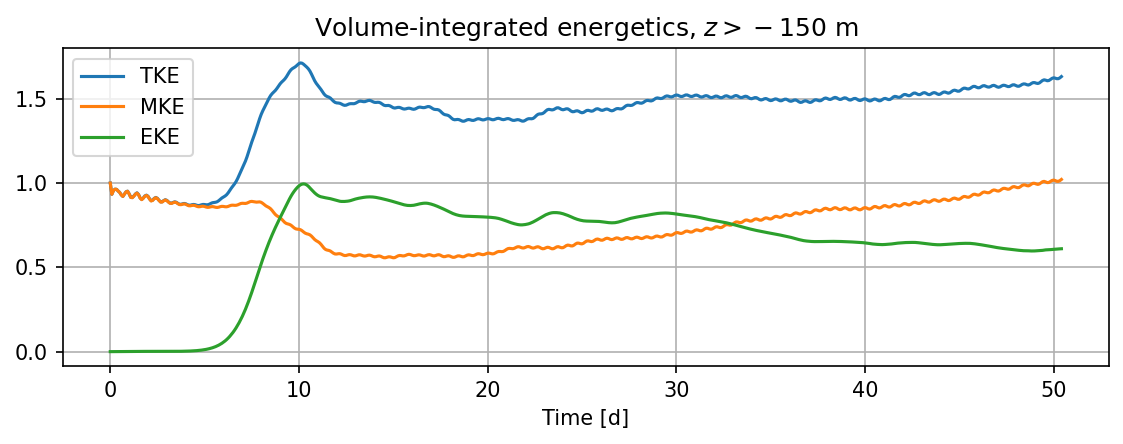

In [13]:
# Plot energetics
fig, ax = plt.subplots(1,1, figsize=(9,2.75),dpi=150)

# Normalize by initial MKE so the total energy is one
plt.plot(time, dse.tke / dse.tke[0], label = 'TKE')
plt.plot(time, dse.mke / dse.mke[0], label = 'MKE')
plt.plot(time, dse.eke / dse.mke[0], label = 'EKE')

plt.grid()
plt.legend()
plt.xlabel('Time [d]')
plt.title('Volume-integrated energetics, $z>-150$ m')

### Calculate N2 using your .in file. This needs to be checked for each run!

```
!              rho(:,:,:) = R0 - R0 * TCOEF * (t(:,:,:,:,itemp) - T0)
!                              + R0 * SCOEF * (t(:,:,:,:,isalt) - S0)
!
!              Typical values:     R0 = 1027.0  kg/m3
!                                  T0 = 10.0    Celsius
!                                  S0 = 35.0    nondimensional
!                               TCOEF = 1.7d-4  1/Celsius
!                               SCOEF = 7.6d-4  1/nondimensional
```

In [14]:
R0    = 1025.0     # kg/m^3
T0    = 1       # Celsius
S0    = 31       # nondimensional
TCOEF = 1.7e-4     # 1/Celsius
SCOEF = 7.6e-4     # 1/nondimensional

# density calculation
rho = (
    R0
    - R0 * TCOEF * (ds.temp - T0)
    + R0 * SCOEF * (ds.salt - S0)
)
rho.name = 'rho'
N2 = xroms.N2(rho, grid, rho0=1025.0)
# Interpolate to rho points
N2_rho = grid.interp(N2, 'Z', boundary = 'extend')

# Compute PDF, normalize by max value so the max is one
n2_bins = np.arange(-5.5,-2.5,0.05)

n2_pdf = histogram(np.log10(N2_rho).where(ds.z_rho>-150), 
                   bins = n2_bins, 
                   dim = ['s_rho','xi_rho', 'eta_rho'],
                   density=True).compute()
n2_pdf = n2_pdf / n2_pdf.max()

In [15]:
# Time vector
time = n2_pdf['ocean_time']
t0 = time.values[0]

time_num = np.array([
    (t - t0).total_seconds() / 86400
    for t in time.values
])

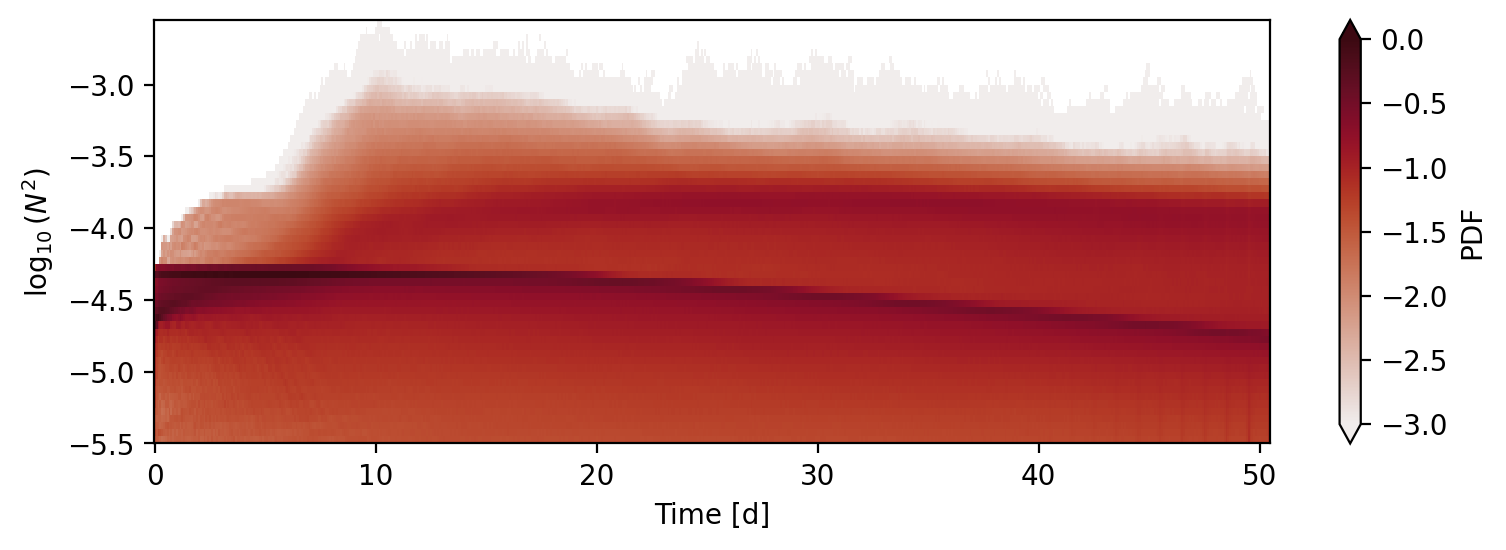

In [16]:
# Plot N2
fig, ax = plt.subplots(figsize=(9, 2.75), dpi=200)

pcm = ax.pcolormesh(
    time_num,
    n2_pdf.N2_bin,
    np.log10(n2_pdf.T.where(n2_pdf.T > 0)),
    shading='auto',
    cmap=cmo.amp,
    vmin=-3, vmax=0
)

ax.set_xlabel('Time [d]')
ax.set_ylabel(r'$\log_{10}(N^2)$')

cbar = fig.colorbar(pcm, ax=ax, extend='both')
cbar.set_label('PDF')

plt.show()


### There is still some striping, so we could probably get away with less bins. Alternatively, use contourf.
Physically - this looks different than the plume case because the jet only occupies a small portion of the domain volume. There are two trends: the mean line, which decreases because winds are causing vertical mixing, which destroys stratification, and the increase in $N^2$ due to the formation of baroclinic instabilities. Since the eddies spread N-S, it's not obvious we should restrict our analysis to the initial conditions where the jet is. I think it makes sense to keep the whole thing 

### Calculate M2. There is no built in xroms function for this, defined as $\sqrt{(\partial_x b)^2 + (\partial_y b )^2}$. 
Note that this will likely be some mismatch due to what we prescribed in the initital conditions, because buoyancy was setup in terms of salt only. Also, this will eat up a lot of memory -- likely need a compute node for 500 m dx grids. 

In [17]:
g = 9.807
# buoyancy
b = -g * ( (rho-R0) / R0)
# Calculate horizontal gradients accounting for s-coordinate
# NOT needed if looking at surface only, then a simple grid.diff will do!
dbdx, dbdy = xroms.hgrad(b.where(ds.z_rho>-150),grid)
dbdx = xroms.to_rho(dbdx,grid)
dbdx = grid.interp(dbdx,'Z')
dbdy = xroms.to_rho(dbdy,grid)
dbdy = grid.interp(dbdy,'Z')


M2 = np.sqrt(dbdx**2+dbdy**2)

# Compute PDF, normalize by max value so the max is one
m2_bins = np.arange(-8,-5.,0.05)
m2_pdf = histogram(np.log10(M2), 
                   bins = m2_bins, 
                   dim = ['xi_rho', 'eta_rho','s_rho'],
                   density=True).compute()
m2_pdf = m2_pdf / m2_pdf.max()

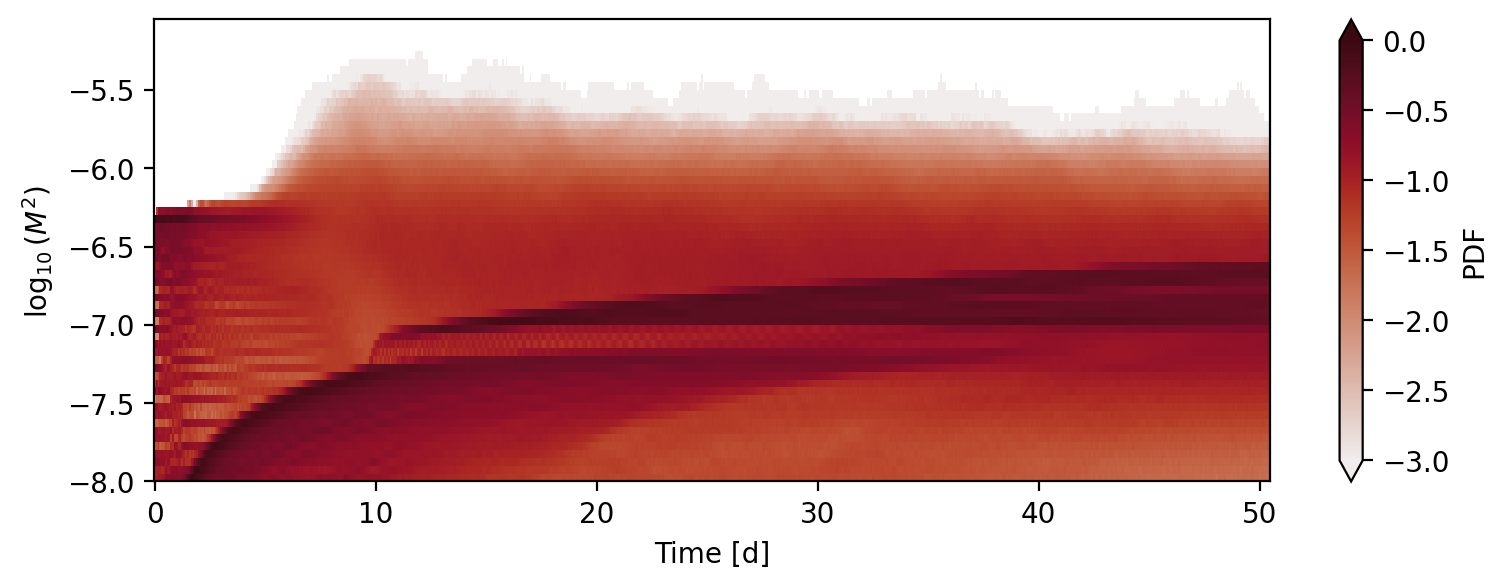

In [107]:
# Plot M2
fig, ax = plt.subplots(figsize=(9, 3), dpi=200)

pcm = ax.pcolormesh(
    time_num,
    m2_pdf.drhodxi_bin,
    np.log10(m2_pdf.T.where(m2_pdf.T > 0)),
    shading='auto',
    cmap=cmo.amp,
    vmin=-3, vmax=0
)

ax.set_xlabel('Time [d]')
ax.set_ylabel(r'$\log_{10}(M^2)$')

cbar = fig.colorbar(pcm, ax=ax, extend='both')
cbar.set_label('PDF')

plt.show()

### Like $N^2$, there are two regimes. 
We can see the jet is initialized with similar M2 than the .in, in this example ```M2_jet=5e-7```. In this plot, the band appears around 10^-6.5~3.17e-7. As the eddies develop, the gradients sharpen, enhancing a weak band of M2. But the mean ocean state is much lower since it starts off with no lateral salt stratification. That band of lower gradients is likely caused by bulk fluxes + sea ice outside the eddy field

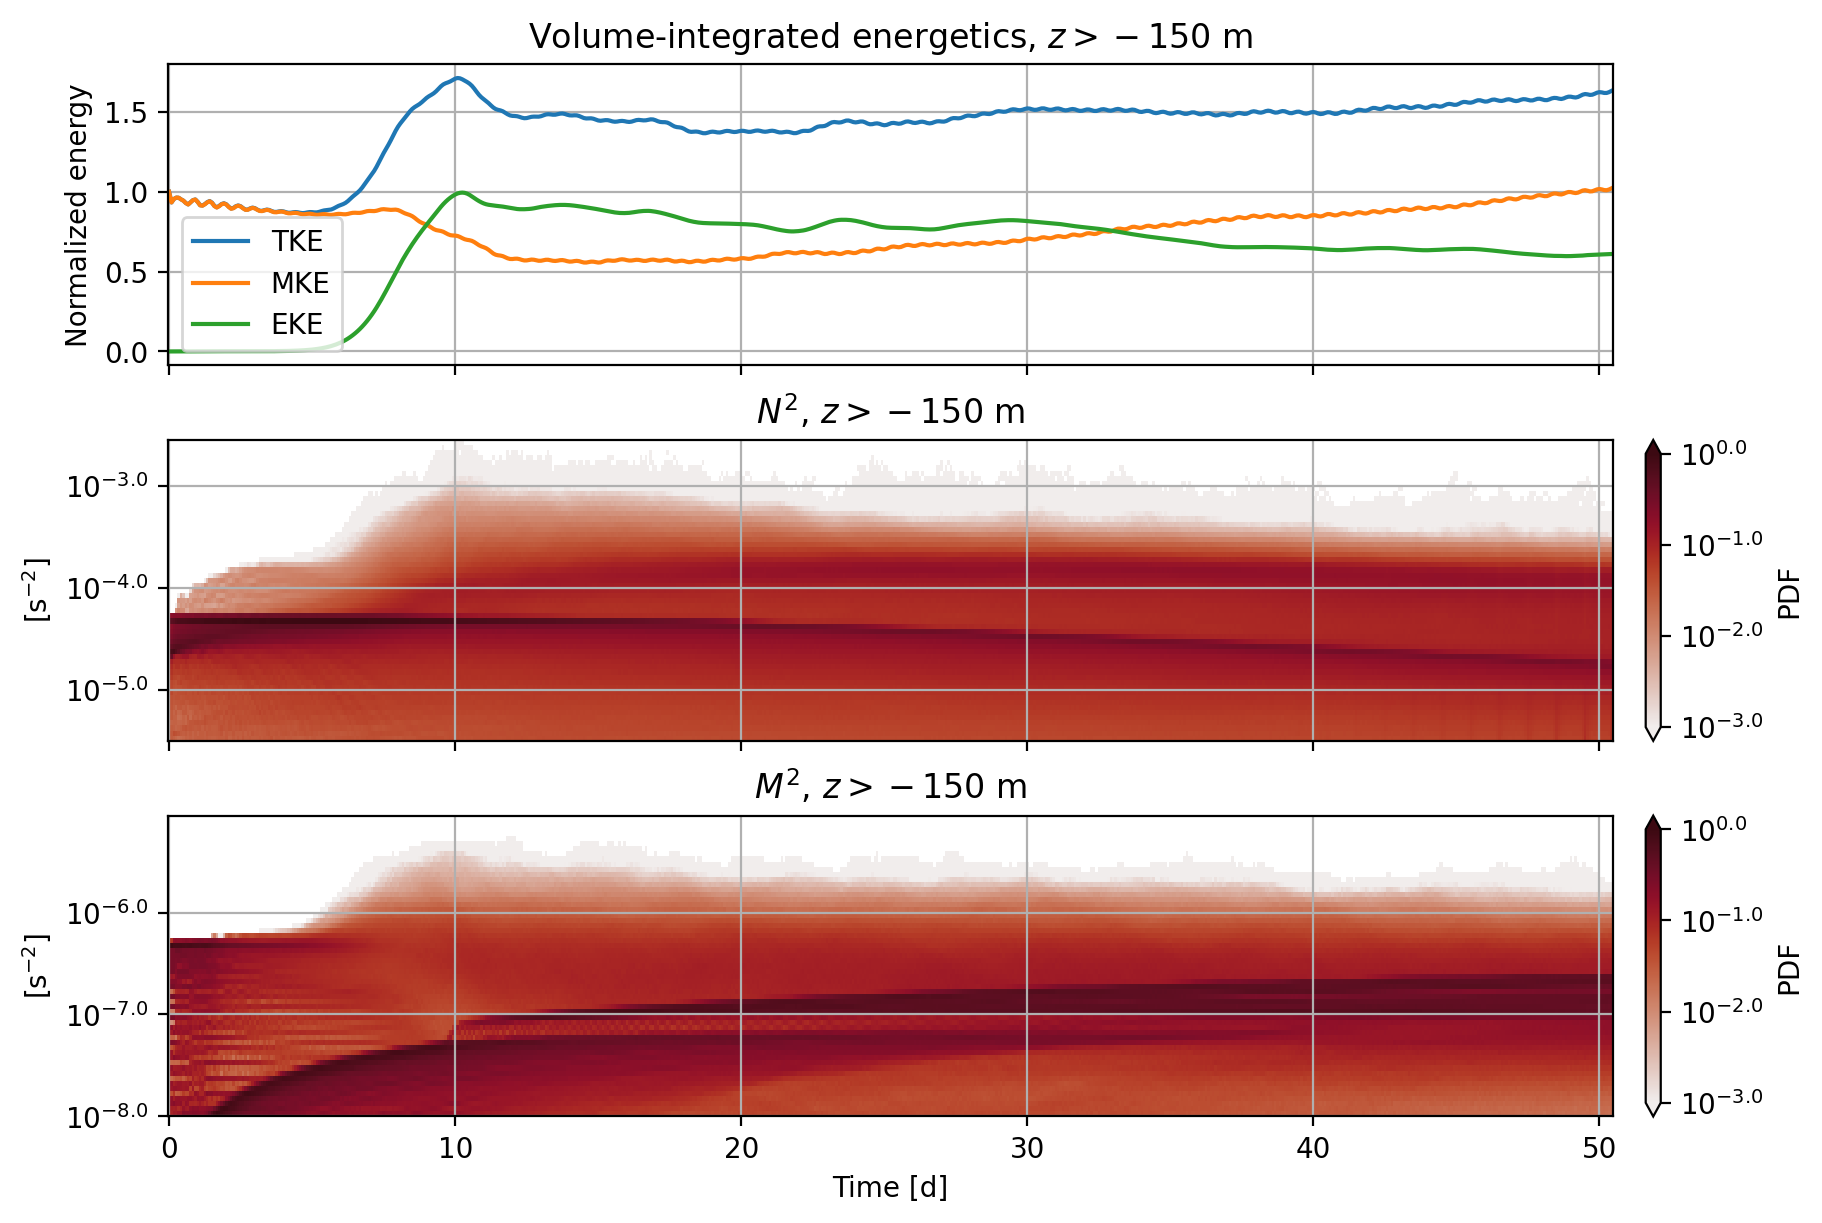

In [36]:
fig, axs = plt.subplots(
    3, 1,
    figsize=(9, 6),
    dpi=200,
    sharex=True,
    constrained_layout=True
)

# ======================
# 1) Energetics (top)
# ======================
ax = axs[0]

ax.plot(time_num, dse.tke / dse.tke[0], label='TKE')
ax.plot(time_num, dse.mke / dse.mke[0], label='MKE')
ax.plot(time_num, dse.eke / dse.mke[0], label='EKE')

ax.set_ylabel('Normalized energy')
ax.set_title('Volume-integrated energetics, $z > -150$ m')
ax.grid()
ax.legend(loc='best')


# ======================
# 2) N² PDF (middle)
# ======================
ax = axs[1]

pcm_n2 = ax.pcolormesh(
    time_num,
    n2_pdf.N2_bin,
    np.log10(n2_pdf.T.where(n2_pdf.T > 0)),
    shading='auto',
    cmap=cmo.amp,
    vmin=-3, vmax=0
)

def ten_power_formatter(x, pos):
    return rf'$10^{{{x:.1f}}}$'

ax.set_ylabel(r'[s$^{-2}$]')
ax.yaxis.set_major_formatter(FuncFormatter(ten_power_formatter))
ax.grid()
ax.set_title('$N^2$, $z>-150$ m')

cbar_n2 = fig.colorbar(
    pcm_n2, ax=ax, extend='both', pad=0.02, format=ticker.FormatStrFormatter('$10^{%.1f}$')
)
cbar_n2.set_label('PDF')


# ======================
# 3) M² PDF (bottom)
# ======================
ax = axs[2]

pcm_m2 = ax.pcolormesh(
    time_num,
    m2_pdf.drhodxi_bin,
    np.log10(m2_pdf.T.where(m2_pdf.T > 0)),
    shading='auto',
    cmap=cmo.amp,
    vmin=-3, vmax=0, 
)

ax.set_xlabel('Time [d]')
ax.set_ylabel(r'[s$^{-2}$]')
ax.yaxis.set_major_formatter(FuncFormatter(ten_power_formatter))
ax.set_title('$M^2$, $z>-150$ m')
ax.grid()

cbar_m2 = fig.colorbar(
    pcm_m2, ax=ax, extend='both', pad=0.02, format=ticker.FormatStrFormatter('$10^{%.1f}$')
)
cbar_m2.set_label('PDF')

plt.show()
